In [1]:
import os

os.getcwd()

'/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation'

In [2]:
os.listdir()

['Research_Paper.pdf',
 'Sentinal-2',
 '.DS_Store',
 'EuroSat',
 'ML models for earth observation.ipynb',
 '.ipynb_checkpoints']

In [41]:
base_path = "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation"

In [43]:
import os

os.listdir(base_path)

['Research_Paper.pdf',
 'Sentinal-2',
 '.DS_Store',
 'EuroSat',
 'ML models for earth observation.ipynb',
 '.ipynb_checkpoints']

In [45]:
eurosat_path = base_path + "/EuroSat"
sentinel_path = base_path + "/Sentinal-2"

In [47]:
print(os.listdir(eurosat_path))
print(os.listdir(sentinel_path))

['.DS_Store', 'EuroSAT', 'EuroSATallBands']
['sentinel_2', '.DS_Store', 'EuroSAT']


In [49]:
!pip install torch torchvision

In [50]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [51]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.2.2
0.17.2


In [58]:
import os
from torchvision import datasets, transforms

eurosat_path = "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/EuroSat"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

eurosat_dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

print("Dataset size:", len(eurosat_dataset))
print("Classes:", eurosat_dataset.classes)

Dataset size: 54597
Classes: ['EuroSAT', 'EuroSATallBands']


In [60]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

In [62]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=len(eurosat_dataset.classes))
model.to(device)

print(device)

cpu


In [66]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [68]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

In [72]:
eurosat_path = '/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/EuroSat'

In [74]:
import os

for item in os.listdir(eurosat_path):
    print(item)

.DS_Store
EuroSAT
EuroSATallBands


In [76]:
for root, dirs, files in os.walk(eurosat_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-"*50)
    break

ROOT: /Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/EuroSat
DIRS: ['EuroSAT', 'EuroSATallBands']
FILES: ['.DS_Store']
--------------------------------------------------


In [78]:
import os

print(os.listdir(eurosat_path))

['.DS_Store', 'EuroSAT', 'EuroSATallBands']


In [80]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)

Dataset size: 54597
Classes: ['EuroSAT', 'EuroSATallBands']


In [82]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [84]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))  
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [86]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=len(dataset.classes)).to(device)

print(device)

cpu


In [92]:
import rasterio
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [108]:
def sentinel_tif_loader(path):
    with rasterio.open(path) as src:
        img = src.read()   

    img = img.astype("float32")   
    img = torch.from_numpy(img)

    img = img / 10000.0

    return img

In [110]:
data_dir = "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/EuroSat/EuroSATallBands"

dataset = ImageFolder(
    root=data_dir,
    loader=sentinel_tif_loader
)

print(dataset.classes)
print(len(dataset))

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
27597


In [112]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [114]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [116]:
import torch.nn as nn
import torchvision.models as models

model = models.resnet50(weights=None)

model.conv1 = nn.Conv2d(
    13, 64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

In [120]:
epochs = 1

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 2.3823


In [119]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 12.481884057971014


In [123]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [125]:
dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

In [127]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [139]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)  

epochs = 1

In [133]:
import rasterio
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

data_dir = "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/EuroSat/EuroSATallBands"

def sentinel_tif_loader(path):
    with rasterio.open(path) as src:
        img = src.read()   # 13 bands, shape: (13, H, W)

    img = img.astype("float32")
    img = torch.from_numpy(img)
    img = img / 10000.0

    return img

dataset = ImageFolder(
    root=data_dir,
    loader=sentinel_tif_loader
)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27597
Image batch shape: torch.Size([16, 13, 64, 64])
Label batch shape: torch.Size([16])


In [137]:
for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.1880


In [138]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 89.2572463768116


In [143]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[520   0   0   3   0   2  64   5   3   0]
 [ 23 552   4   0   0   0   0   0   0   0]
 [ 13   5 414   3   3   7 138   9   2   2]
 [  4   1   0 431  10   2   8   5  10   0]
 [  0   0   0   9 446   0   1  10   1   0]
 [ 49   4   4   9   0 298  42   0   6   1]
 [ 12   2   2   2   0   2 415  88   2   0]
 [  0   1   0   1   8   0   0 603   0   0]
 [  1   0   1   6   0   0   0   0 523   1]
 [  0   0   0   0   0   0   0   0   2 725]]


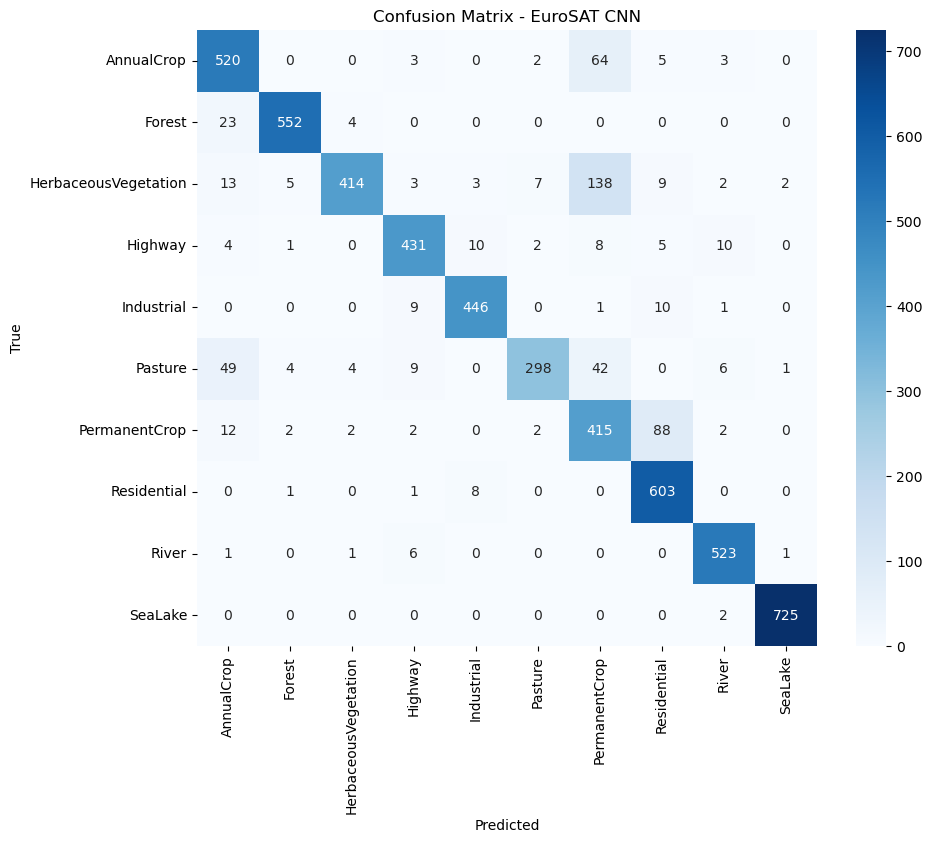

In [145]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - EuroSAT CNN")
plt.show()

In [147]:
print(classification_report(y_true, y_pred, target_names=dataset.classes))

                      precision    recall  f1-score   support

          AnnualCrop       0.84      0.87      0.85       597
              Forest       0.98      0.95      0.97       579
HerbaceousVegetation       0.97      0.69      0.81       596
             Highway       0.93      0.92      0.92       471
          Industrial       0.96      0.96      0.96       467
             Pasture       0.96      0.72      0.82       413
       PermanentCrop       0.62      0.79      0.70       525
         Residential       0.84      0.98      0.90       613
               River       0.95      0.98      0.97       532
             SeaLake       0.99      1.00      1.00       727

            accuracy                           0.89      5520
           macro avg       0.90      0.89      0.89      5520
        weighted avg       0.90      0.89      0.89      5520



In [149]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio

In [153]:
sentinel_path = "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/Sentinal-2/sentinel_2"
print(os.listdir(sentinel_path))

['.DS_Store', 'ds']


In [157]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
import rasterio

class SentinelDataset(Dataset):
    def __init__(self, root):
        self.root = root

        self.classes = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ])

        self.images = []
        self.labels = []

        for idx, cls in enumerate(self.classes):
            class_path = os.path.join(root, cls)

            for r, _, files in os.walk(class_path):
                for file in files:
                    if file.lower().endswith((".tif", ".tiff")):
                        self.images.append(os.path.join(r, file))
                        self.labels.append(idx)

        print("Total images loaded:", len(self.images))
        print("Classes:", self.classes)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]
        label = self.labels[idx]

        with rasterio.open(path) as src:
            img = src.read()

        img = img[:3, :, :]

        img = np.transpose(img, (1, 2, 0))

        img = img.astype(np.float32) / 255.0

        img = torch.from_numpy(img)

        img = img.permute(2, 0, 1)

        return img, label

In [159]:
sentinel_dataset = SentinelDataset(sentinel_path)

Total images loaded: 27000
Classes: ['ds']


In [161]:
def __getitem__(self, idx):
    path = self.images[idx]
    label = self.labels[idx]

    with rasterio.open(path) as src:
        img = src.read()  

    img = img[:3] 

    img = np.transpose(img, (1, 2, 0)) 

    img = torch.from_numpy(img.astype(np.float32))  

    img = img.permute(2, 0, 1) / 10000.0  

    return img, label

In [163]:
img, label = sentinel_dataset[0]

print(img.shape)
print(img.dtype)
print(img.min(), img.max())
print(label)

torch.Size([3, 64, 64])
torch.float32
tensor(2.1686) tensor(4.6078)
0


In [165]:
from torch.utils.data import DataLoader

loader = DataLoader(sentinel_dataset, batch_size=32, shuffle=False)

In [167]:
import torch
import torch.nn as nn

In [169]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [171]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=10)
model = model.to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)


In [175]:
eurosat_path = "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/Sentinal-2/EuroSAT"

In [177]:
from torchvision import datasets, transforms

In [179]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [181]:
eurosat_dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

print(len(eurosat_dataset))
print(eurosat_dataset.classes)

27000
['2750']


In [183]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(eurosat_dataset))
test_size = len(eurosat_dataset) - train_size

train_dataset, test_dataset = random_split(
    eurosat_dataset,
    [train_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [185]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [191]:
epochs = 3

model.train()

for epoch in range(epochs):
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 0.0
Epoch 2, Loss: 0.0
Epoch 3, Loss: 0.0


In [193]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("EuroSAT Accuracy:", 100 * correct / total)

EuroSAT Accuracy: 100.0


In [195]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [197]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [199]:
sentinel_path = "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/Sentinal-2/sentinel_2"

sentinel_dataset = datasets.ImageFolder(
    root=sentinel_path,
    transform=transform
)

print(len(sentinel_dataset))
print(sentinel_dataset.classes)

27000
['ds']


In [201]:
sentinel_loader = DataLoader(
    sentinel_dataset,
    batch_size=32,
    shuffle=False
)

In [203]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

In [205]:
class SafeSentinelDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []
        self.classes = sorted(os.listdir(root))

        for label, cls in enumerate(self.classes):
            class_path = os.path.join(root, cls)

            if not os.path.isdir(class_path):
                continue

            for file in os.listdir(class_path):
                if file.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.images.append(os.path.join(class_path, file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [207]:
sentinel_dataset = SafeSentinelDataset(
    root='/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/Sentinal-2/sentinel_2',
    transform=transform
)

In [209]:
sentinel_loader = DataLoader(sentinel_dataset, batch_size=32, shuffle=False)

In [211]:
model.eval()

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)

In [213]:
import os
import torch
from torch.utils.data import Dataset
import rasterio
import numpy as np

In [215]:
class SentinelDataset(Dataset):
    def __init__(self, root):
        self.images = []
        self.labels = []
        self.classes = sorted(os.listdir(root))

        for label, cls in enumerate(self.classes):
            class_path = os.path.join(root, cls)

            if not os.path.isdir(class_path):
                continue

            for file in os.listdir(class_path):
                if file.endswith(".tif"):
                    self.images.append(os.path.join(class_path, file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]
        label = self.labels[idx]

        with rasterio.open(path) as src:
            img = src.read()

        img = img[:3]

        img = np.transpose(img, (1, 2, 0)).astype(np.float32)

        img = img / np.max(img)

        img = torch.tensor(img).permute(2, 0, 1)

        return img, label

In [217]:
sentinel_path = '/Users/monicachaganti/Desktop/Ph.D/PROJECTS/ML models for Earth observation/Sentinal-2/sentinel_2/ds/images/remote_sensing/otherDatasets/sentinel_2/tif'

In [219]:
sentinel_dataset = SentinelDataset(sentinel_path)

In [221]:
print("Samples:", len(sentinel_dataset))
print("Classes:", sentinel_dataset.classes)

Samples: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [223]:
print(len(sentinel_dataset))

27000


In [225]:
from torch.utils.data import DataLoader

sentinel_loader = DataLoader(
    sentinel_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [227]:
print(len(sentinel_loader.dataset))

27000


In [229]:
images, labels = next(iter(sentinel_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 64, 64]) torch.Size([32])


In [231]:
images, labels = next(iter(sentinel_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 64, 64]) torch.Size([32])


In [233]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in sentinel_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Sentinel-2 Accuracy:", 100 * correct / total)

Sentinel-2 Accuracy: 11.11111111111111


In [235]:
results = []

results.append({
    "Model": "CNN",
    "EuroSAT Accuracy": 100.0,
    "Sentinel-2 Accuracy": 11.11111111111111,
    "Accuracy Drop": 100.0 - 11.11111111111111
})

In [237]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [239]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [243]:
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)


In [247]:
nn.Conv2d(13, 32, kernel_size=3, padding=1)

Conv2d(13, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [251]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [263]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

resnet_model = models.resnet18(weights=None)

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)

resnet_model = resnet_model.to(device)

In [265]:
optimizer = optim.Adam(resnet_model.parameters(), lr=0.0001)

In [267]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.0001)

epochs = 5

for epoch in range(epochs):
    resnet_model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.0262
Epoch 2, Loss: 0.0004
Epoch 3, Loss: 0.0002
Epoch 4, Loss: 0.0001
Epoch 5, Loss: 0.0001


In [276]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [278]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

resnet_model.eval()
with torch.no_grad():
    outputs = resnet_model(images)
    _, predicted = torch.max(outputs, 1)

print("Actual:", labels[:10].cpu().numpy())
print("Predicted:", predicted[:10].cpu().numpy())

Actual: [0 0 0 0 0 0 0 0 0 0]
Predicted: [0 0 0 0 0 0 0 0 0 0]


In [282]:
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Classes:", dataset.classes)

Train size: 21600
Test size: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [284]:
from collections import Counter

train_labels = [dataset.targets[i] for i in train_dataset.indices]
test_labels = [dataset.targets[i] for i in test_dataset.indices]

print("Train distribution:", Counter(train_labels))
print("Test distribution:", Counter(test_labels))

Train distribution: Counter({2: 2402, 9: 2394, 0: 2392, 1: 2384, 7: 2363, 3: 2054, 6: 2009, 8: 2000, 4: 1996, 5: 1606})
Test distribution: Counter({7: 637, 1: 616, 0: 608, 9: 606, 2: 598, 4: 504, 8: 500, 6: 491, 3: 446, 5: 394})


In [288]:
print(len(dataset))

27597


In [290]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Total:", len(train_dataset) + len(test_dataset))

Train size: 22077
Test size: 5520
Total: 27597


In [292]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [296]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

resnet_model = models.resnet18(weights=None)

resnet_model.conv1 = nn.Conv2d(
    13, 64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)

resnet_model = resnet_model.to(device)

In [298]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.0001)

In [300]:
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([32, 13, 64, 64])


In [302]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

resnet_model = models.resnet18(weights=None)

resnet_model.conv1 = nn.Conv2d(
    13, 64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)

resnet_model = resnet_model.to(device)

In [304]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.0001)

epochs = 5

for epoch in range(epochs):
    resnet_model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.5560
Epoch 2, Loss: 0.3164
Epoch 3, Loss: 0.2387
Epoch 4, Loss: 0.1962
Epoch 5, Loss: 0.1473


In [305]:
print(resnet_model.conv1)

Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)


In [308]:
resnet_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 88.93%


In [310]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

resnet_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=dataset.classes))

                      precision    recall  f1-score   support

          AnnualCrop       0.73      0.97      0.83       631
              Forest       0.98      0.92      0.95       593
HerbaceousVegetation       0.94      0.87      0.90       588
             Highway       0.86      0.79      0.82       500
          Industrial       0.90      0.95      0.92       469
             Pasture       0.83      0.95      0.89       382
       PermanentCrop       0.75      0.72      0.73       493
         Residential       0.97      0.77      0.86       619
               River       0.97      0.94      0.96       496
             SeaLake       0.99      0.99      0.99       749

            accuracy                           0.89      5520
           macro avg       0.89      0.89      0.89      5520
        weighted avg       0.90      0.89      0.89      5520



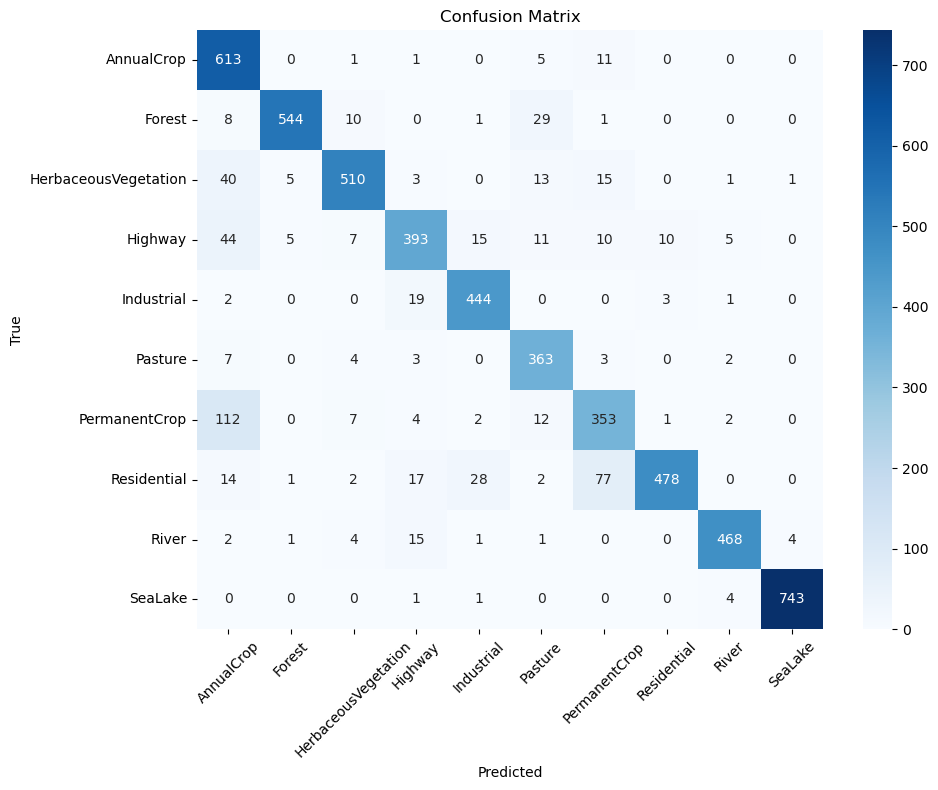

In [312]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

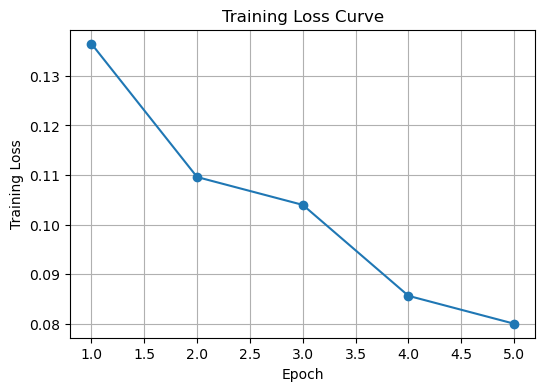

In [315]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

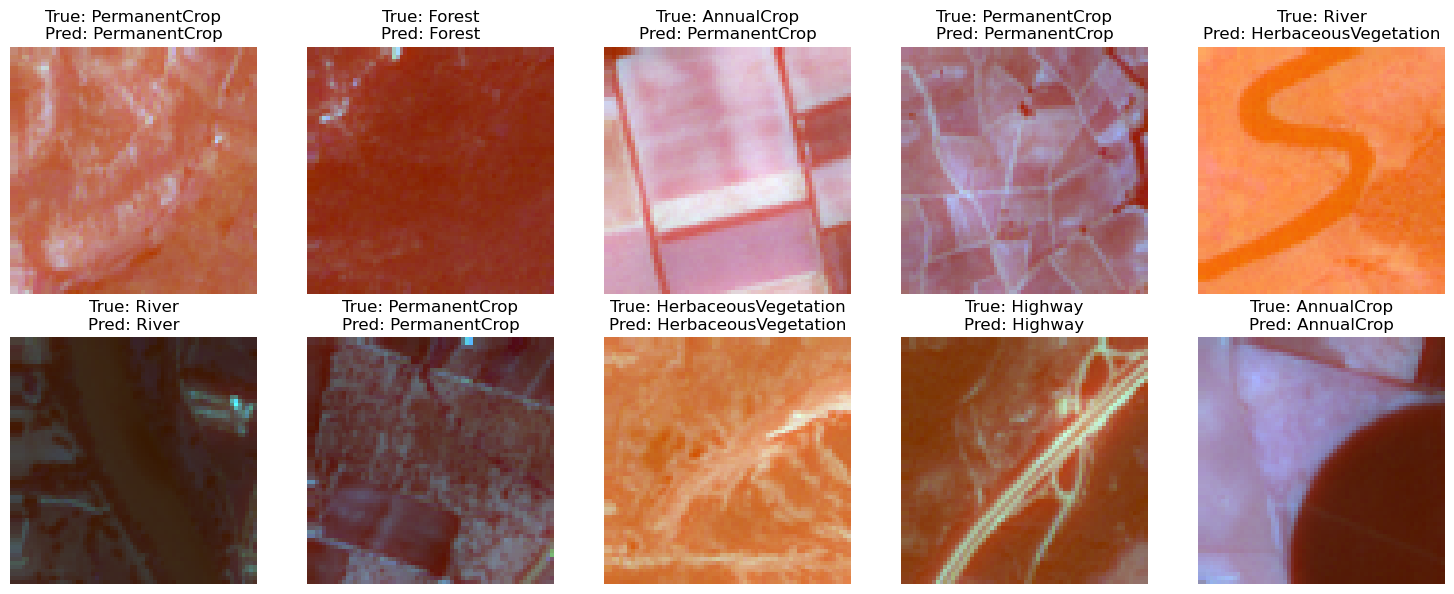

In [317]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

images_device = images.to(device)

resnet_model.eval()
with torch.no_grad():
    outputs = resnet_model(images_device)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    
    img = images[i][:3].permute(1, 2, 0).numpy()

    img = (img - img.min()) / (img.max() - img.min())

    ax.imshow(img)
    ax.set_title(
        f"True: {dataset.classes[labels[i]]}\nPred: {dataset.classes[preds[i].cpu()]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [319]:
torch.save(resnet_model.state_dict(), "resnet18_13bands.pth")

In [321]:
resnet_model.load_state_dict(torch.load("resnet18_13bands.pth"))
resnet_model.eval()

ResNet(
  (conv1): Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
 